# Data Visualization

### 1. Extraction of the data

We begin by importing the essential libraries required for data handling, visualization, and model development.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.dummy import DummyRegressor
import seaborn as sns

All necessary tools are now loaded, allowing us to proceed with data extraction and analysis.

Next, we load the red and white wine datasets to explore their structure and content.

In [2]:
red_wine = pd.read_csv("../data/raw/winequality-red.csv", sep=";")
white_wine = pd.read_csv("../data/raw/winequality-white.csv", sep=";")

red_wine.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


The dataset is successfully loaded, and a quick preview helps us understand the available features.

### 2. Preparation features and target

We now separate the input features from the target variable we aim to predict.

In [6]:
# Features (X) and target (y)
X = red_wine.drop("quality", axis=1)
y = red_wine["quality"]

The data is now structured into predictors (X) and target (y), ready for modeling.

To evaluate our models properly, we split the data into training and testing sets.

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

The dataset is now divided, allowing us to train models and assess their performance on unseen data.

### 3. Visualization of the data

#### 3.1 Format of the data and missing data

We begin the exploration by examining the structure of the dataset, its statistical properties, and checking for any missing values.

In [7]:
# Shape and basic info
print(red_wine.shape)
print(red_wine.info())

# Statistical summary
red_wine.describe()

# Check missing values
red_wine.isnull().sum()

(1599, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB
None


fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

The dataset contains 1,599 observations with no missing values, confirming that the data is clean and ready for further analysis.

#### 3.2 Distribution of the Target (Quality)

We now examine how the target variable (wine quality) is distributed across the dataset.

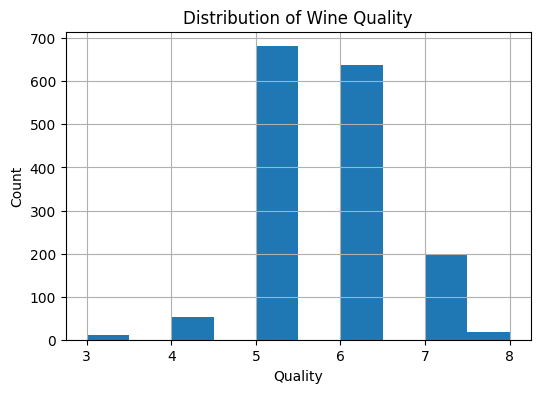

In [9]:
plt.figure(figsize=(6,4))
red_wine['quality'].hist(bins=10)
plt.title("Distribution of Wine Quality")
plt.xlabel("Quality")
plt.ylabel("Count")
plt.show()

Most wines cluster around quality 5-6
So this is an imbalanced dataset (significant for our ML analysis)

#### 3.3 Feature Distributions 

Next, we visualize the distribution of all features to better understand their ranges and patterns.

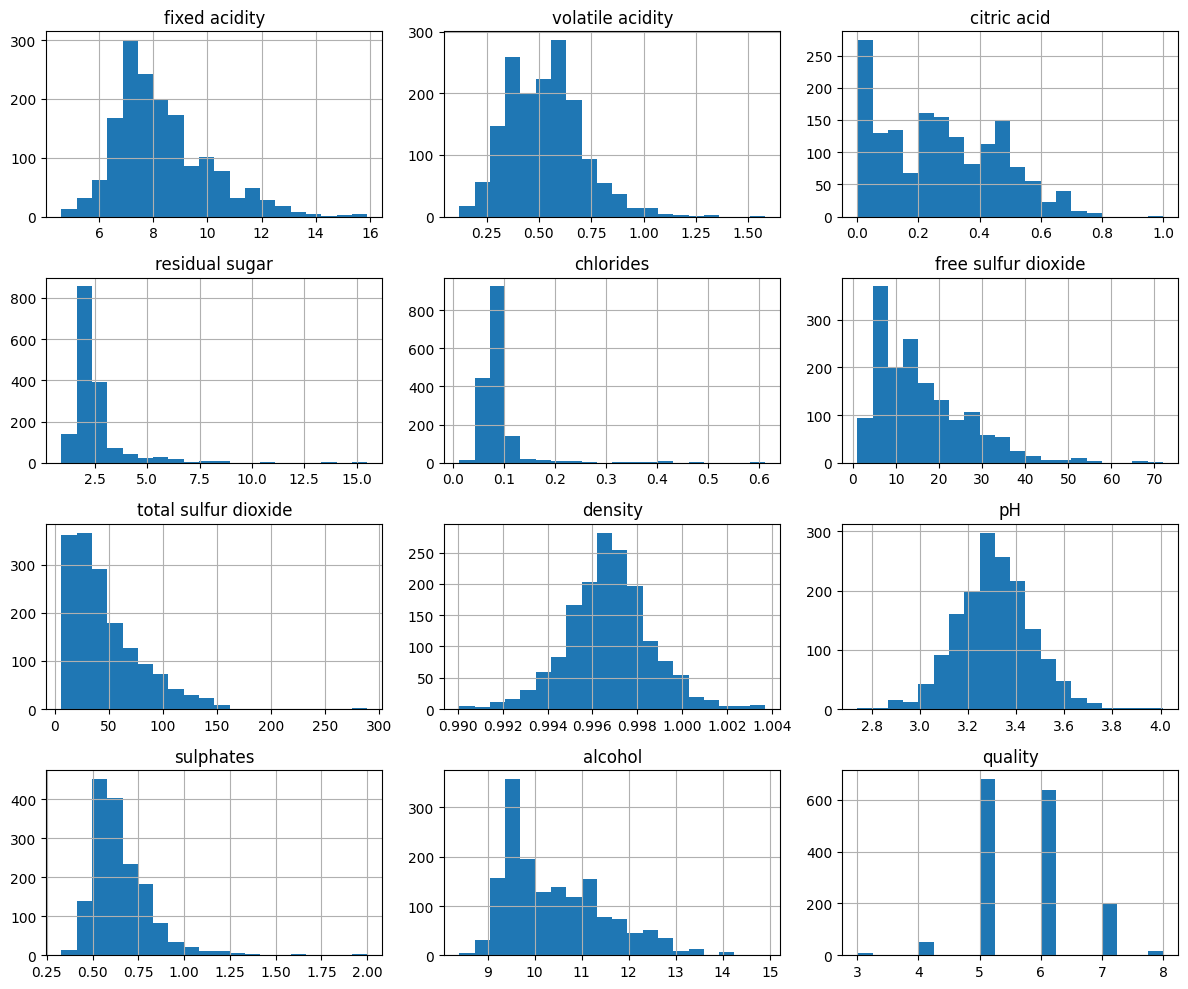

In [10]:
red_wine.hist(bins=20, figsize=(12,10))
plt.tight_layout()
plt.show()

##### Feature n°1: Fixed Acidity 
- Range: ~4.5 to 16
- Peak: 7–8
- Distribution: approximately normal, slight right skew
- Majority: 6–9
  
##### Feature n°2: Volatile Acidity 
- Range: ~0.1 to 1.6
- Peak: 0.3-0.4 and 0.55 to 0.65
- Distribution: right-skewed
- Majority: 0.3–0.7
  
##### Feature n°3: Citric Acid
- Range: 0.0 to 1.0
- Peak: 0.0–0.1, and smaller ones at 0.2–0.35 and 0.45-0.55
- Distribution: irregular 
- Many values near 0.0

##### Feature n°4: Residual Sugar 
- Range: ~0.5 to 15.5
- Peak: 1.5–2.5
- Distribution: highly right-skewed
- Majority: 1–3
  
##### Feature n°5: Chlorides
- Range: ~0.01 to 0.6
- Peak: 0.05–0.09
- Distribution: strong right skew
- Majority: <0.12

##### Feature n°6: Free Sulfur Dioxide
- Range: ~1 to 72
- Peak: 5–15
- Distribution: right-skewed
- Majority: 5–30

##### Feature n°7: Total Sulfur Dioxide
- Range: ~5 to 290
- Peak: 20–60
- Distribution: strong right-skew
- Majority: <100

##### Feature n°8: Density
- Range: 0.990 to 1.003
- Peak: 0.996–0.998
- Distribution: approximately normal
- Very low variance (tight clustering)

##### Feature n°9: pH
- Range: 2.8 to 4.0
- Peak: 3.2–3.4
- Distribution: normal
 -Majority: 3.0–3.6

##### Feature n°10: Sulphates
- Range: 0.3 to 2.0
- Peak: 0.5–0.7
- Distribution: right-skewed
- Majority: 0.4–0.8

##### Feature n°11: Alcohol
- Range: 8.5 to 15
- Peak: 9.5–10.5
- Distribution: slight right skew
- Majority: 9–11.5

##### Target: Quality
- Range: 3 to 8 (integer values only)
- Most frequent values:
5 (~680 samples) / 6 (~640 samples)
- Minority classes:
3 (<20 samples) / 8 (<20 samples)
- Distribution: discrete, imbalanced

All the features are continous, but the target variable (quality) is categorical (int values : 0 to 10).

#### 3.4 Outlier detection (boxplots)

To better identify outliers, we standardize the features and visualize them using boxplots.

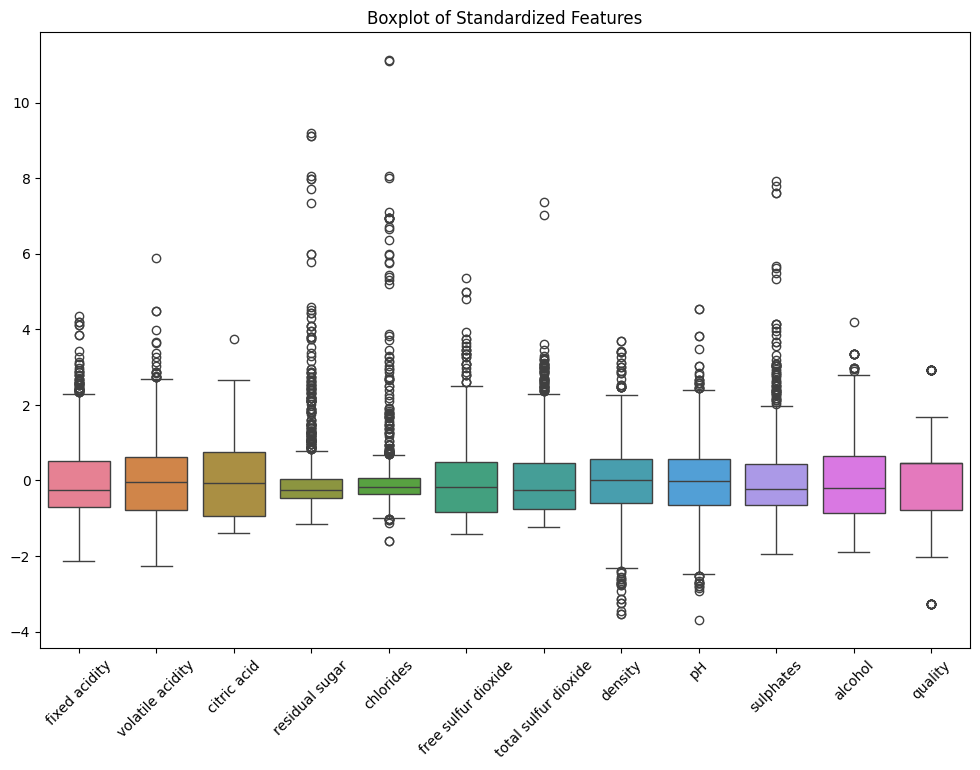

In [33]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_data = scaler.fit_transform(red_wine)

scaled_df = pd.DataFrame(scaled_data, columns=red_wine.columns)

plt.figure(figsize=(12,8))
sns.boxplot(data=scaled_df)
plt.xticks(rotation=45)
plt.title("Boxplot of Standardized Features")
plt.show()

After standardization, all features are on the same scale (centered around 0), making comparison easier. Most data points lie between -2 and +2, but several features still show many outliers, especially residual sugar, chlorides, and sulphates. This means these variables have extreme values compared to others. Overall, the data is not perfectly normal and contains variability.

#### 3.5 Correlation matrix

We now explore the relationships between variables using a correlation matrix.

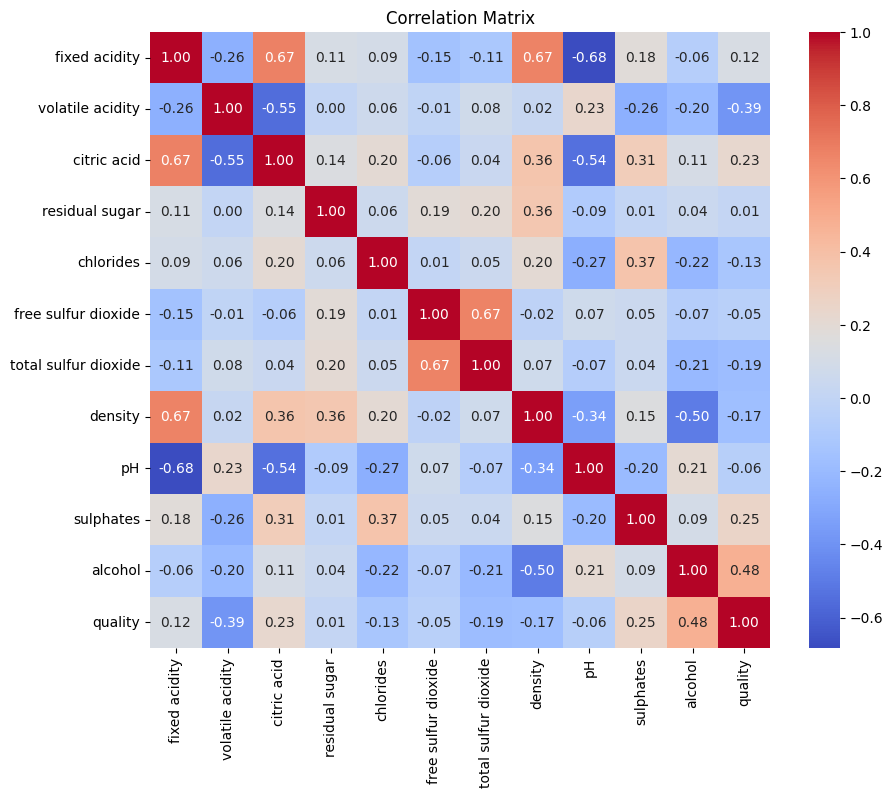

In [20]:
plt.figure(figsize=(10,8))
corr = red_wine.corr()

sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

##### Relationship with Quality:
The correlation matrix shows that alcohol (0.48) has the strongest positive relationship with quality, while volatile acidity (-0.39) has the strongest negative impact. 

Sulphates (0.25) and citric acid (0.23) also positively influence quality. Most other features have weak correlations. 

#### 3.6 Correlation matrix with target (quality)

We focus on how each feature correlates specifically with the target variable (quality).

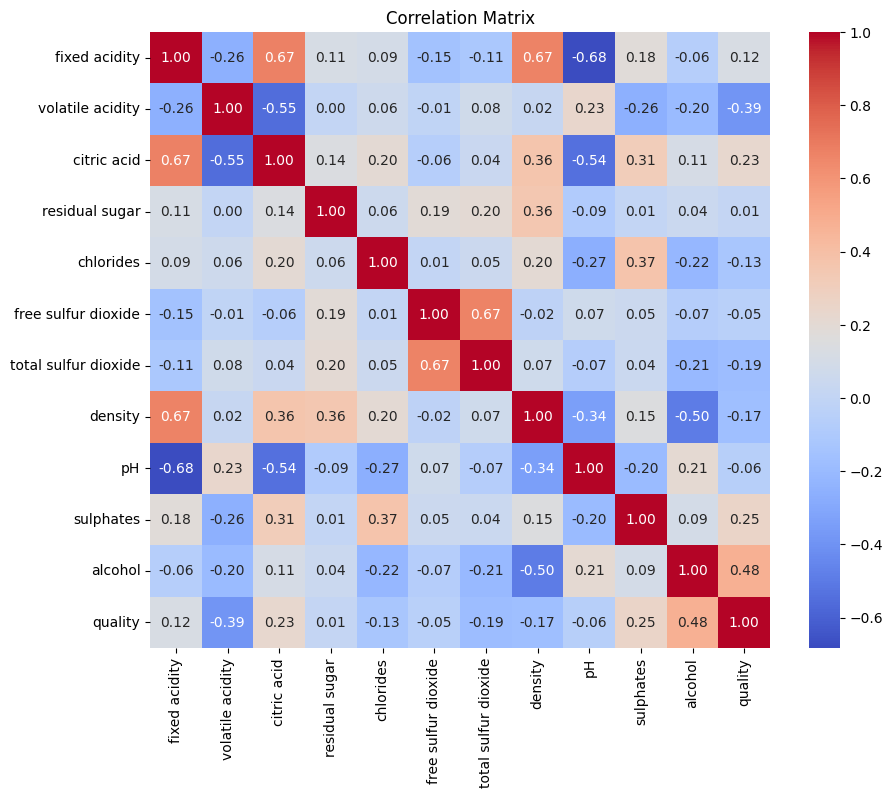

In [21]:
plt.figure(figsize=(10,8))
corr = red_wine.corr()

sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

The correlation matrix shows several strong relationships between features. Fixed acidity and citric acid (0.67), as well as free and total sulfur dioxide (0.67), are highly correlated, indicating possible redundancy. Fixed acidity and pH (-0.68) show a strong negative relationship. Moderate correlations appear between density and alcohol (-0.50) and citric acid and pH (-0.54). Most other feature pairs have weak correlations (between -0.3 and 0.3), suggesting low linear dependency across the dataset.

#### 3.7 Visualise Key Relationships

##### 3.7.1 Alcohol vs Quality

We now examine the relationship between alcohol content and wine quality.

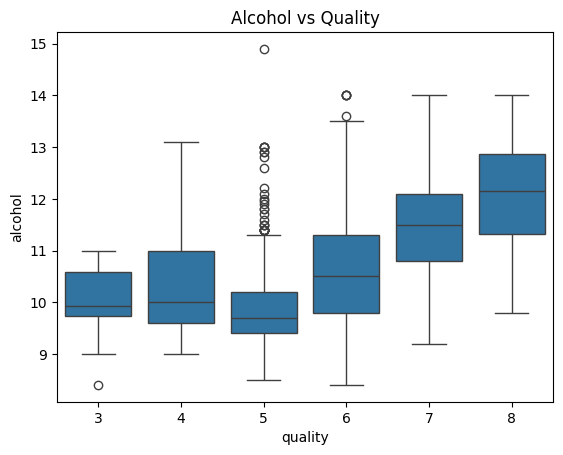

In [24]:
sns.boxplot(x='quality', y='alcohol', data=red_wine)
plt.title("Alcohol vs Quality")
plt.show()

The boxplot shows that alcohol levels increase steadily across quality categories. Median alcohol rises from about 9.8 (quality 3–4) to around 12.2 (quality 8). Higher quality groups (7–8) have wider ranges, reaching up to 14–15, while lower qualities are more concentrated between 9–11. There are several outliers, especially in quality 5, but the overall trend is clearly upward.

##### 3.7.2 Feature Relationships (multivariate insight)

We further explore the relationships between key variables to better understand their interactions.

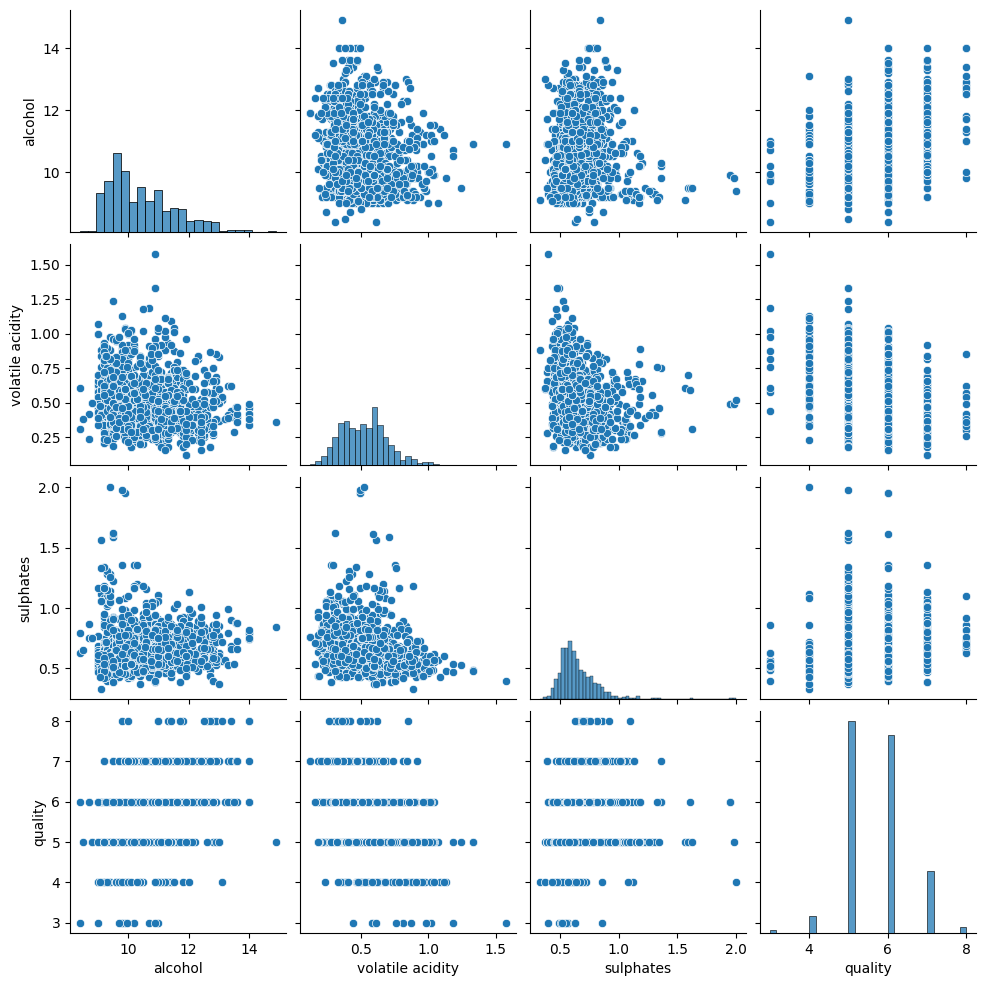

In [28]:
sns.pairplot(red_wine[['alcohol', 'volatile acidity', 'sulphates', 'quality']])
plt.show()

Alcohol shows a slight positive relationship with quality (points trend upward). Volatile acidity tends to decrease as quality increases (downward spread). Sulphates show a weak positive trend with alcohol. Most points cluster around mid-quality values, indicating limited separation between classes.